In [16]:
import sys
from pathlib import Path

path = str(Path.cwd().parent)
if path not in sys.path:
    sys.path.append(path)

from Src.Models.Network import Network
from Src.Models.Component import Port, Ground, L, C
from Src.Models.Circuit import Circuit


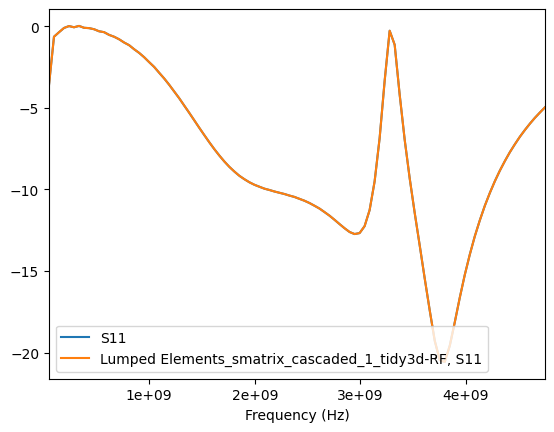

In [ ]:
short_snp = Network.from_touchstone("../Data/Touchstone/Lumped Elements_smatrix_cascaded_1_tidy3d-RF.s1p")
rf_snp = Network.from_touchstone("../Data/Touchstone/Lumped Elements_smatrix_tidy3d-RF.s4p")

port1 = Port(name='port1', frequency=rf_snp.frequency, z0=[50.0, 0.0])
gnd1 = Ground(name='gnd1', frequency=rf_snp.frequency, z0=[50.0, 0.0])
gnd2 = Ground(name='gnd2', frequency=rf_snp.frequency, z0=[50.0, 0.0])

networks = {
    'port1': port1,
    'gnd1': gnd1,
    'gnd2': gnd2,
    'rf_snp': rf_snp
}

connections = [
    [
        ('port1', 0),
        ('rf_snp', 0)
    ],
    [
        ('gnd1', 0),
        ('rf_snp', 1)
    ],
    [
        ('gnd2', 0),
        ('rf_snp', 2)
    ],
]

rf_circuit = Circuit(networks=networks, connections=connections)
skrf_circuit = rf_circuit.to_circuit()
skrf_circuit.network.plot_s_db()
short_snp.to_network().plot_s_db()

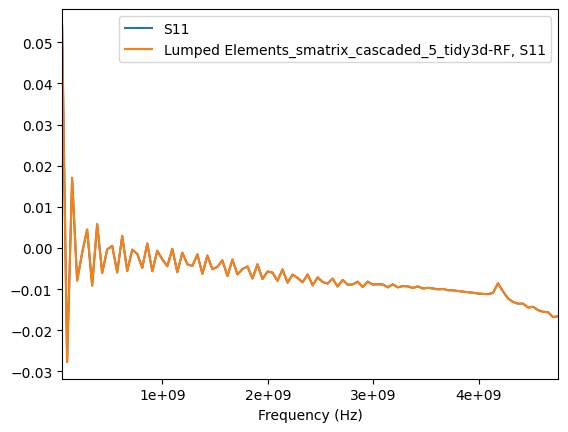

In [21]:
capacitor = C(c=100e-6, name='capacitor', frequency=rf_snp.frequency, z0=[50.0, 0.0])
inductor = L(l=10e-6, name='inductor', frequency=rf_snp.frequency, z0=[50.0, 0.0])
gnd3 = Ground(name='gnd3', frequency=rf_snp.frequency, z0=[50.0, 0.0])

combined_snp = Network.from_touchstone("../Data/Touchstone/Lumped Elements_smatrix_cascaded_5_tidy3d-RF.s1p")
networks = {
    'port1': port1,
    'gnd1': gnd1,
    'gnd2': gnd2,
    'rf_snp': rf_snp,
    'capacitor': capacitor,
    'inductor': inductor,
    'gnd3': gnd3
}

connections = [
    [
        ('port1', 0),
        ('rf_snp', 0)
    ],
    [
        ('gnd1', 0),
        ('rf_snp', 1)
    ],
    [
        ('inductor', 0),
        ('rf_snp', 2)
    ],
    [
        ('gnd2', 0),
        ('inductor', 1)
    ],
    [
        ('rf_snp', 3),
        ('capacitor', 0)
    ],
    [
        ('gnd3', 0),
        ('capacitor', 1)
    ]
]

rf_circuit = Circuit(networks=networks, connections=connections)
skrf_circuit = rf_circuit.to_circuit()
skrf_circuit.network.plot_s_db()
combined_snp.to_network().plot_s_db()

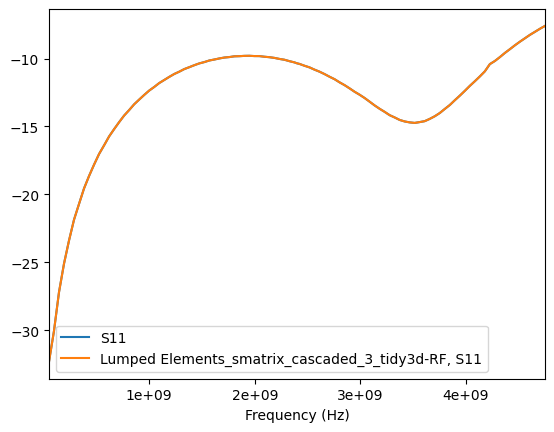

In [14]:
inductor = L(l=10e-6, name='inductor', frequency=rf_snp.frequency, z0=[50.0, 0.0])
inductor_snp = Network.from_touchstone("../Data/Touchstone/Lumped Elements_smatrix_cascaded_3_tidy3d-RF.s1p")
networks = {
    'port1': port1,
    'gnd1': gnd1,
    'gnd2': gnd2,
    'rf_snp': rf_snp,
    'inductor': inductor
}

connections = [
    [
        ('port1', 0),
        ('rf_snp', 0)
    ],
    [
        ('gnd1', 0),
        ('rf_snp', 1)
    ],
    [
        ('inductor', 0),
        ('rf_snp', 2)
    ],
    [
        ('gnd2', 0),
        ('inductor', 1)
    ],
]

rf_circuit = Circuit(networks=networks, connections=connections)
skrf_circuit = rf_circuit.to_circuit()
skrf_circuit.network.plot_s_db()
inductor_snp.to_network().plot_s_db()